In [10]:
import scipy
import numpy as np
from numpy.polynomial import polynomial as P
import matplotlib as mpl
import matplotlib.pyplot as plt

# Data Analysis for Experiment 2

## Introduction

This workbook will guide you through the computations associated with our ro-vibrational experiment. Before
starting the notebook, be sure to read through the background given in the lab handout. We are interested in computing a variety of spectroscopic constants, namely,
 - $\tilde{\nu}_e$, the equilibrium vibrational frequency
 - $B_e$,  the rotaional constant
 - $\tilde{\nu}_e\chi_e$, anharmonic vibrational correction
 - $D_e$, the centrifugal distortion constant
 - $\alpha_e$, the vibrational-rotational interaction constant
 - $k$, the force constant
 - $I_e$, the moment of inertia
 - $r_e$, the equilibrium bond length
 
For many of these constants, we can compute them from a variety of known relations.
For example, the rotational constant, which we'll get experimentally is related to the moment of inertia,
$$ B_e = \frac{h}{8\pi^2cI_e}$$
and the moment of intertial gives us a way to compute $r_e$,
$$ I_e = \mu r_e^2 $$
where $\mu$ is the reduced mass.
Similarly, knowledge of $\tilde{\nu}_e$ allows us to compute the force constant, using the relation,
$$\tilde{\nu}_e = \frac{1}{2\pi c}\Big(\frac{k}{\mu}\Big)^{1/2}$$.
 
For $\tilde{\nu}_e$ and $\tilde{\nu}_e\chi_e$, we can use their relation to the forbidden transition of the Q branch,
$$\tilde{\nu}_0 = \tilde{\nu}_e - 2\tilde{\nu}_e\chi_e$$
which can be derived from equation 7 in the lab handout.
As we will see, $\tilde{\nu}_0$ is obtained directly from the data. We can use this equation with
$$D_e = \frac{4B_e^3}{\tilde{\nu}_e}$$
to obtain $\tilde{\nu}_e$.

From the above equations, we now have a means of determining $\tilde{\nu}_e$, $\tilde{\nu}_e\chi_e$, $k$, $I_e$, and $r_e$. How then do we get $B_e$, $D_e$, $\alpha_e$, and $\tilde{\nu}_0$? If we combine equations 8 and 9 in the handout, and substitute the definition of $m$ also from the handout, we get,
$$\tilde{\nu}(m) = \tilde{\nu}_0 + (2B_e - 2\alpha_e)m - \alpha_em^2-4D_em^3$$
where $\tilde{\nu}(m)$ are our peak locations. So, from a list of $m$ values and $\tilde{\nu}(m)$ values, we can fit a polynomial equation to get each of the constants. We will do this using linear, quadratic, and cubic fits. First, I'll provide some data for the DCl molecule. Then, you will repeat the exercise using your data for HCl.

### 1. Ro-vibrational constants for DCl
#### The raw data
In the cell below, I've provided the peak positions (in wavenumbers) and the $m$ values for a DCl rovibrational spectrum, similar to the HCl one you will take. I've also provided a simple command to plot the data.

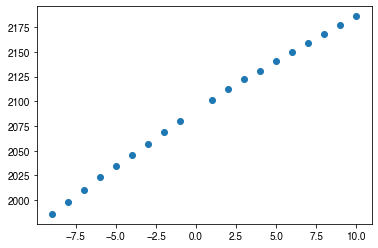

In [23]:
peaks = [1986, 1998, 2010, 2023, 2034, 2046, 2057, 2069, 2080, 2101, 2112, 2122, 2131, 2141, 2150, 2159, 2168, 2177,2186]
ms = [-9,-8,-7,-6,-5,-4,-3,-2,-1,1,2,3,4,5,6,7,8,9,10]
plt.scatter(ms, peaks)

We will obtain necessary spectroscopic constants by fitting the above plot. We'll start with a linear fit:

#### Linear fit
If we take our DCl molecule as strictly a harmonic oscillator and rigid rotator, we have no distortion, anharmonic, or rotation-vibration coupling effects. What results is a linear expression for our peak positions and $m$ values,
$$\tilde{\nu}(m) = \tilde{\nu}_0 + 2B_em$$
This is an equation of the forn $y=mx+b$. Therefore, if we perform a linear fit of our data, we will get $\tilde{\nu}_0$ as the $y$-intercept and $2B_e$ as the slope. This is in line with our knowledge of the rigid rotator, where the peaks are spaced by $2B_e$. We can fit the data using the cell below,

In [40]:
# a linear fit
# the function takes 'x' and 'y' values,
# in addition to an integer to determine the 
# polynomial order. Here, its 1

c, stats = P.polyfit(ms,peaks,1, full=True)

# c is a list of the form [intercept, slope], and stats is a
# set of data telling us the goodness of our fit.

# here's a little code to get the R^2 value
TSS = 0.0
for p in peaks:
    TSS += p*p 
r_squared = 1 - stats[0]/TSS   

# Let's print the values
print("Coefficients: " + str(c))
print("R^2: " + str(r_squared))


Coefficients: [2086.56294537   10.5304038 ]
R^2: [0.99999741]


So, the fit seems pretty good. We also see that $\tilde{\nu}_0 = 2086.562$ and $2B_e = 10.530$. In the cell below, record the value of $\tilde{\nu}_e$ and $B_e$. Note in this case, there is no $\tilde{\nu}_e\chi_e$ term.

In the cells below, use these values to determine $I_e$, $r_e$, and $k$. Be sure to record these in your notebook as well.

#### Quadratic fit

We can begin including correcting terms to get, theoretically, more accurate values of our constants. When we include the vibrational-rotational correction, $\alpha_e$, we get,
$$\tilde{\nu}(m) = \tilde{\nu}_0 + (2B_e - 2\alpha_e)m - \alpha_em^2 $$
This equation requires a quadratic fit due to the $m^2$. In the cell below, paste the code from above to perform a quadratic fit. You will only need to change one part of the code before entering to have the code run the quadratic fit rather than the linear one.

In [41]:
### Your code here




Coefficients: [ 2.09052012e+03  1.06413020e+01 -1.13873543e-01]
R^2: [0.99999997]


Take note if the fit improved or worsened (by looking at R^2). Now, we see that we have three coefficients. These coefficients are displayed as [c b a], for an equation of the form $y = c + bx + ax^2$. 

In the cell below, use the output coefficents to determine an updated $\tilde{\nu}_e$, $B_e$, and $\alpha_e$. You can do the math either in the cell or in your notebook, but display them below.

In the cells below, use these values to determine a new $I_e$, $r_e$, and $k$. Be sure to record these in your notebook as well, labelling them in a way distinct from those determined from the linear fit. If you do it here, you can add more cells as needed.

#### Cubic fit

Finally, when we add in the anharmonicity constant and the distortion constant, we get,
$$\tilde{\nu}(m) = \tilde{\nu}_0 + (2B_e - 2\alpha_e)m - \alpha_em^2-4D_em^3$$
This requires us to fit an equation of the form $y = d + cx + bx^2 + ax^3$. Because we now have $D_e$, we can use the equation, $\tilde{\nu}_0 = \tilde{\nu}_e - 2\tilde{\nu}_e\chi_e$ to get a corrected $\tilde{\nu}_e$ and anharmonicity constant $\tilde{\nu}_e\chi_e$.

Using the same code from the previous fits, perform the cubic fit in the cell below. Again, there is only one small change needed to go from quadratic to cubic.

In [ ]:
### Your code here



This time, we have four coefficients, output in the order [d c b a]. In report in the cells below the values of $\tilde{\nu}_0$, $B_e$, $\alpha_e$, and $D_e$. Be sure to have them here and in your lab notebook.

Use the equation $D_e = \frac{4B_e^3}{\tilde{\nu}_e}$ to obtain a value of ${\tilde{\nu}_e}$. Record it below and in your notebook.

Using this value and the equation, $\tilde{\nu}_0 = \tilde{\nu}_e - 2\tilde{\nu}_e\chi_e$, determine the anharmonicity constant $\tilde{\nu}_e\chi_e$.

Again, using your values, compute $I_e$, $r_e$, and $k$ using the constants from the cubic fit. Record these here and in your notebook.

### 2. Ro-vibrational constants of HCl

Now, we are going to perform all of these calculations again, but instead with the data you record for the HCl molecule. 

First we need to define our $m$ values and our peak locations. In the cell below VERY CAREFULLY fill each list (separated by commas) with your $m$ values and peak locations (use wavenumbers) IN ORDER. Executing the cell will also plot the values.

In [ ]:
m = []
peaks = []
plt.scatter(m, peaks)

#### Linear Fit
Use the previous code to compute $\tilde{\nu}_e$, $B_e$, $I_e$, $r_e$, and $k$. Perform the fitting in the next cell, and compute/record the constants here and in your notebook.

In [42]:
### Your fitting code

#### Quadratic fit
Use the previous code to compute $\tilde{\nu}_e$, $B_e$, $I_e$, $r_e$, $\alpha_e$, and $k$. Perform the fitting in the next cell, and compute/record the constants here and in your notebook.

In [ ]:
### Your fitting code

#### Cubic fit
Use the previous code to compute $\tilde{\nu}_e$, $B_e$, $I_e$, $\alpha_e$, $r_e$, $k$, $D_e$, and $\tilde{\nu}_e\chi_e$. Perform the fitting in the next cell, and compute/record the constants here and in your notebook.

### 3. Isotope Effect

By this point we have many values for our spectroscopic constants for HCl and DCl. In nex week's lab, we will compute more of these using other methods, plotting our fits, and comparing to literature values. One important comparison to literature is the isotope effect. Essentially, we are interested in how the two primary constants for rotations and vibrations change between the HCl and DCl isotopes. The first quantity we want is 
$$\tilde{\nu}^*_0/\tilde{\nu}_0$$
where $\tilde{\nu}^*_0$ is the value for DCl determined from cubic fitting, and $\tilde{\nu}^*_0$ is the value from HCl determined from cubic fitting. Compute and pring this value using the cell below:

Similarly, we can do this for the rotational constant, where the ratio
$$B_e^*/B_e$$
gives us information about how this constant changes with the isotopes. Again, $B_e^*$ is determined from the cubic fit for DCl, and $B_e$ is also the cubic fit for HCl. In the cell below, compute and print this ratio.

Be sure to have both of these ratios in your lab notebook.